# 🌍 Search & Load CMIP6 Data via ESGF / OPeNDAP

This notebook searches for and loads CMIP6 climate model output directly over the network using
[**Earth System Grid Federation**](https://esgf.llnl.gov/) (ESGF) infrastructure — the backbone of the CMIP6 distribution system.

Two technologies do the heavy lifting:

| Technology | Role |
|---|---|
| [**esgf-pyclient**](https://esgf-pyclient.readthedocs.io/en/latest/) | Discover *which* files hold the data we want, searching federally across all ESGF nodes |
| [**OPeNDAP**](https://www.opendap.org/) | Stream those files lazily over HTTP — no full download |

**What we'll do**

1. Query ESGF for daily near-surface air temperature (`tas`) under the **SSP5-8.5** scenario
2. Open the remote files lazily with `xarray` + `dask`
3. Map the temperature field on a proper geographic projection
4. Build an **area-weighted global-mean** temperature series
5. Compute the **warming trend** over the 21st century projection period

> ⚠️ **Live data.** Cells pull from ESGF nodes in real time. If a search or load cell errors, it is almost always a node being temporarily down — re-run, or try a different `source_id` from the search results.

## ⚙️ Setup

Imports plus a little plot styling so the figures look clean.

In [ ]:
import os

os.environ["ESGF_PYCLIENT_NO_FACETS_STAR_WARNING"] = "1"

import pandas as pd
import xarray as xr
from pyesgf.search import SearchConnection

import matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cfeature

xr.set_options(display_style='html')
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# --- light, consistent plot styling ---
mpl.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'font.size': 11,
})

## 🔎 Search using esgf-pyclient

The helper below wraps [`pyesgf.search.SearchConnection`](https://esgf-pyclient.readthedocs.io/en/latest/api.html)
from the **esgf-pyclient** library. Pass CMIP6 facets as keyword arguments
(`variable_id`, `experiment_id`, `source_id`, …) and it returns the matching OPeNDAP URLs,
searching **across all federated ESGF nodes** (`distrib=True` by default) so results are not
tied to a single node that may be down.


In [2]:
esgf_node = "http://esgf-data.dkrz.de/esg-search"
conn = SearchConnection(esgf_node, distrib=True)

Search for **daily** near-surface air temperature (`tas`) under the **SSP5-8.5** high-emissions scenario (`ssp585`), ensemble member `r1i1p1f1`, regridded grid (`gr`). The federated search (`distrib=True`) returns files from all ESGF mirror nodes; results are grouped by model in the next cell.

In [ ]:
ctx = conn.new_context(
    project="CMIP6",
    experiment_id="ssp585",
    variable_id="tas",
    grid_label="gr",
    facets="*",
)
print(len(ctx.search()), "files found across mirror nodes.")



-------------------------------------------------------------------------------
Warning - defaulting to search with facets=*

This behavior is kept for backward-compatibility, but ESGF indexes might not
successfully perform a distributed search when this option is used, so some
results may be missing.  For full results, it is recommended to pass a list of
facets of interest when instantiating a context object.  For example,

      ctx = conn.new_context(facets='project,experiment_id')

Only the facets that you specify will be present in the facets_counts dictionary.

This warning is displayed when a distributed search is performed while using the
facets=* default, a maximum of once per context object.  To suppress this warning,
set the environment variable ESGF_PYCLIENT_NO_FACETS_STAR_WARNING to any value
or explicitly use  conn.new_context(facets='*')

-------------------------------------------------------------------------------


234 files found across mirror nodes.


In [4]:
ctx = conn.new_context(
    project="CMIP6",
    experiment_id="ssp585",
    frequency="day",  # not time_frequency
    member_id="r1i1p1f1",  # not ensemble
    variable_id="tas",
    grid_label="gr",
    latest=True,
    facets="*"
)

datasets = ctx.search()
print(f"Found {len(datasets)} datasets.\n")


Found 10 datasets.



In [ ]:
def _v(meta, key):
    v = meta.get(key)
    return v[0] if isinstance(v, list) and v else v

rows = []
for ds in datasets:
    m = ds.json
    urls = [
        f.opendap_url for f in ds.file_context().search() if f.opendap_url
    ]
    if urls:
        rows.append({
            'activity_id':    _v(m, 'activity_id'),
            'institution_id': _v(m, 'institution_id'),
            'source_id':      _v(m, 'source_id'),
            'experiment_id':  _v(m, 'experiment_id'),
            'member_id':      _v(m, 'member_id'),
            'table_id':       _v(m, 'table_id'),
            'variable_id':    _v(m, 'variable_id'),
            'grid_label':     _v(m, 'grid_label'),
            'version':        _v(m, 'version'),
            'opendap_url':    urls,
        })

models = pd.DataFrame(rows)
models


-------------------------------------------------------------------------------
Warning - defaulting to search with facets=*

This behavior is kept for backward-compatibility, but ESGF indexes might not
successfully perform a distributed search when this option is used, so some
results may be missing.  For full results, it is recommended to pass a list of
facets of interest when instantiating a context object.  For example,

      ctx = conn.new_context(facets='project,experiment_id')

Only the facets that you specify will be present in the facets_counts dictionary.

This warning is displayed when a distributed search is performed while using the
facets=* default, a maximum of once per context object.  To suppress this warning,
set the environment variable ESGF_PYCLIENT_NO_FACETS_STAR_WARNING to any value
or explicitly use  conn.new_context(facets='*')

-------------------------------------------------------------------------------

----------------------------------------------------

,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,version,opendap_url
0,ScenarioMIP,NIMS-KMA,KACE-1-0-G,ssp585,r1i1p1f1,day,tas,gr,20200317,[https://esgf.ceda.ac.uk/thredds/dodsC/esg_cmi...
1,ScenarioMIP,EC-Earth-Consortium,EC-Earth3,ssp585,r1i1p1f1,day,tas,gr,20200310,[https://esgf.ceda.ac.uk/thredds/dodsC/esg_cmi...
2,ScenarioMIP,EC-Earth-Consortium,EC-Earth3-CC,ssp585,r1i1p1f1,day,tas,gr,20210113,[https://esgf.ceda.ac.uk/thredds/dodsC/esg_cmi...
3,ScenarioMIP,EC-Earth-Consortium,EC-Earth3-Veg-LR,ssp585,r1i1p1f1,day,tas,gr,20201201,[https://esgf.ceda.ac.uk/thredds/dodsC/esg_cmi...
4,ScenarioMIP,IPSL,IPSL-CM6A-LR,ssp585,r1i1p1f1,day,tas,gr,20190903,[https://esgf.ceda.ac.uk/thredds/dodsC/esg_cmi...
5,ScenarioMIP,IPSL,IPSL-CM6A-LR,ssp585,r1i1p1f1,day,tas,gr,20190903,[http://vesg.ipsl.upmc.fr/thredds/dodsC/cmip6/...
6,ScenarioMIP,IPSL,IPSL-CM6A-LR,ssp585,r1i1p1f1,day,tas,gr,20190903,[http://esgf3.dkrz.de/thredds/dodsC/cmip6/Scen...
7,ScenarioMIP,EC-Earth-Consortium,EC-Earth3,ssp585,r1i1p1f1,day,tas,gr,20200310,[http://esgf3.dkrz.de/thredds/dodsC/cmip6/Scen...
8,ScenarioMIP,EC-Earth-Consortium,EC-Earth3-CC,ssp585,r1i1p1f1,day,tas,gr,20210113,[http://esgf3.dkrz.de/thredds/dodsC/cmip6/Scen...
9,ScenarioMIP,EC-Earth-Consortium,EC-Earth3-Veg-LR,ssp585,r1i1p1f1,day,tas,gr,20201201,[http://esgf3.dkrz.de/thredds/dodsC/cmip6/Scen...


## 📦 Load data with Xarray

The DataFrame above has one row per model. The `opendap_url` column holds a **list** of all file URLs
for that dataset — one URL per time-chunk file. We pick the first available model with `models.iloc[0]`
and open all its OPeNDAP URLs at once with `xr.open_mfdataset`. Change the index to load a different
model from the table (e.g. `models.iloc[2]` for the third row).

In [6]:
model = models.iloc[0]
ds = xr.open_mfdataset(model['opendap_url'], combine="by_coords")
ds

<xarray.Dataset> Size: 3GB
Dimensions:    (time: 30960, bnds: 2, lat: 144, lon: 192)
Coordinates:
  * time       (time) object 248kB 2015-01-01 12:00:00 ... 2100-12-30 12:00:00
  * lat        (lat) float64 1kB -89.38 -88.12 -86.88 ... 86.88 88.12 89.38
  * lon        (lon) float64 2kB 0.9375 2.812 4.688 6.562 ... 355.3 357.2 359.1
    height     float64 8B ...
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 495kB dask.array<chunksize=(30960, 2), meta=np.ndarray>
    lat_bnds   (lat, bnds) float64 2kB dask.array<chunksize=(144, 2), meta=np.ndarray>
    lon_bnds   (lon, bnds) float64 3kB dask.array<chunksize=(192, 2), meta=np.ndarray>
    tas        (time, lat, lon) float32 3GB dask.array<chunksize=(30960, 144, 192), meta=np.ndarray>
Attributes: (12/47)
    Conventions:                     CF-1.7 CMIP-6.2
    activity_id:                     ScenarioMIP
    branch_method:                   standard
    branch_time_in_child:            0.0
    branch_time_in_parent:           0.0
    contact:                         Hyun Min, Sung (sunghm122@korea.kr)
    ...                              ...
    tracking_id:                     hdl:21.14100/b5ca95fb-94dc-425c-81d6-7f2...
    variable_id:                     tas
    variant_label:                   r1i1p1f1
    license:                         CMIP6 model data produced by NIMS-KMA is...
    cmor_version:                    3.4.0
    DODS_EXTRA.Unlimited_Dimension:  time

## 🗺️ Map a single day

Instead of a bare lat/lon grid, we render the field on a **Robinson projection** with coastlines
and a labelled colorbar. SSP5-8.5 data starts in 2015, so we pick a date within that range.

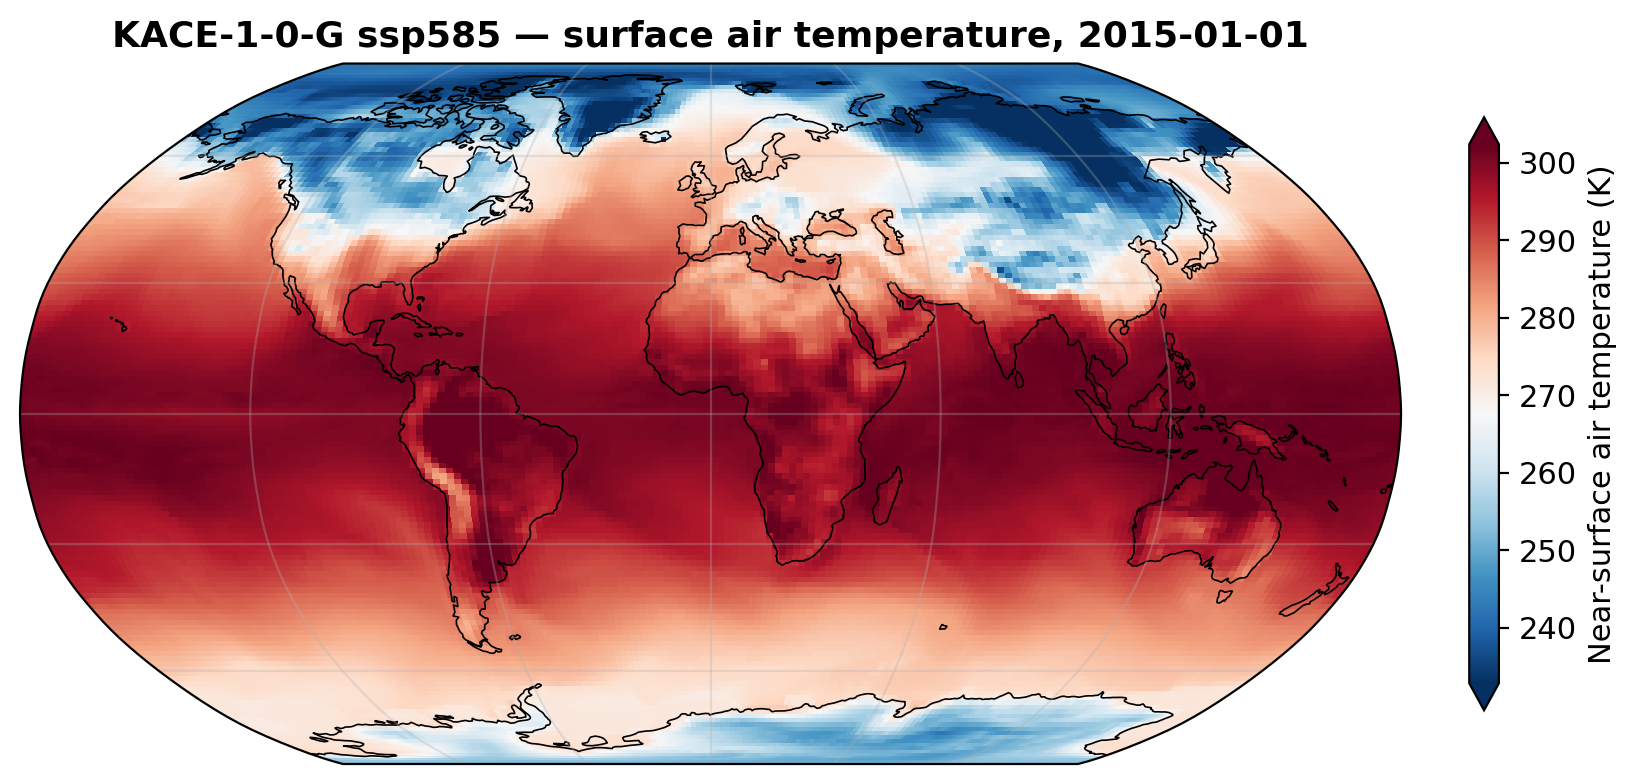

In [7]:
snapshot = ds.tas.isel(time=0).squeeze()
date_str = str(snapshot.time.values)[:10]

fig = plt.figure(figsize=(11, 5.5))
ax = plt.axes(projection=ccrs.Robinson())

p = snapshot.plot(
    ax=ax, transform=ccrs.PlateCarree(),
    cmap='RdBu_r', robust=True,
    cbar_kwargs={'label': 'Near-surface air temperature (K)', 'shrink': 0.7, 'pad': 0.04},
)
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.gridlines(alpha=0.3)
ax.set_global()
ax.set_title(f'{model["source_id"]} {model["experiment_id"]} — surface air temperature, {date_str}', fontweight='bold')
plt.show()

### 📍 Time series at a specific location

Instead of a global mean, extract the temperature at a single grid point using `.sel()` with
`method='nearest'` — xarray snaps to the closest grid cell to your target coordinates.

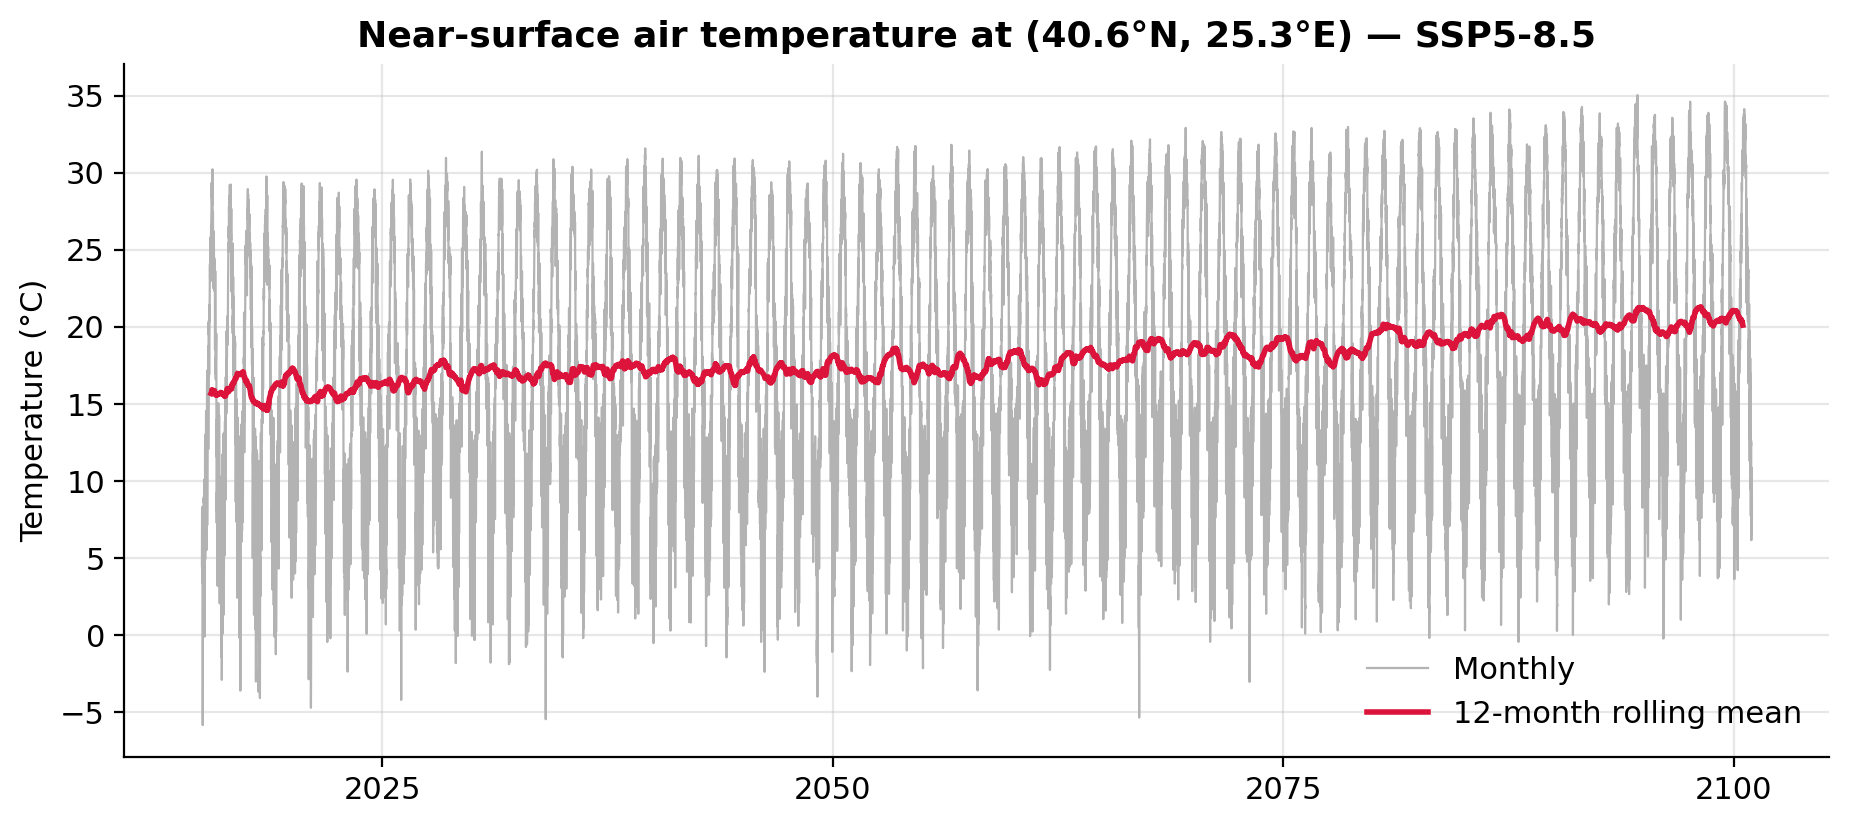

: 

In [ ]:
# Target location — change to any lat/lon you like
target_lat = 41.133  # Xanthi, Greece
target_lon = 24.883

point = ds.tas.sel(lat=target_lat, lon=target_lon, method="nearest")

point_C = point - 273.15  # convert from K to °C


fig, ax = plt.subplots(figsize=(11, 4.5))
point_C.plot(ax=ax, color="0.7", lw=0.8, label="Monthly")
point_C.rolling(time=365, center=True).mean().plot(
    ax=ax, color="crimson", lw=2, label="12-month rolling mean"
)

actual_lat = float(point.lat)
actual_lon = float(point.lon)
ax.set_title(
    f"Near-surface air temperature at ({actual_lat:.1f}°N, {actual_lon:.1f}°E) — SSP5-8.5",
    fontweight="bold",
)
ax.set_ylabel("Temperature (°C)")
ax.set_xlabel("")
ax.legend(frameon=False)
plt.show()


---
## Summary

We used **esgf-pyclient** to search for CMIP6 `tas` output across all federated ESGF nodes,
loaded the first available model's SSP5-8.5 files lazily over OPeNDAP with `xarray` + `dask`,
mapped them on geographic projections, and reduced them to an area-weighted global-mean warming signal.

**Try next**

- Change the index in `models.iloc[0]` to load a different model (e.g. `models.iloc[2]` for EC-Earth3-Veg)
- Change `table_id='day'` to `table_id='Amon'` for monthly data (faster to load, sufficient for climatologies)
- Add `experiment_id='historical'` to extend the time series back to 1850 and compute a pre-industrial baseline
- Search for additional variables (`pr` for precipitation, `psl` for sea-level pressure) using the same pattern